## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "physbo_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "/Users/shibukawar/workspace/nimo-fork/multi_batch_experiments_melting_temperature/./configs/physbo_batch1_trial1.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = config["batch_size"]
TOTAL_EVAL = config["total_eval"]
INITIAL_BATCH_SIZE = config["initial_batch_size"]
print(f"Initial Batch Size: {INITIAL_BATCH_SIZE}")
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

# Create output directory with batch size in name
out_dir = Path(f"./data_physbo_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

Initial Batch Size: 15
CyclesNum: 30


PosixPath('data_physbo_batch1_trial1/physbo_batch1_trial1.yaml')

In [9]:
candidates_file = out_dir / f"mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"mp_proposals_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./mp_search_space_physbo_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "PHYSBO",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_melting_point
    analysis_output_functions_SO_melting_point.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")
end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  435
proposal =  [18. 24.]
###
###
number = 2
actions =  647
proposal =  [28. 48.]
###
###
number = 3
actions =  1011
proposal =  [52. 20.]
###
###
number = 4
actions =  397
proposal =  [16. 34.]
###
###
number = 5
actions =  814
proposal =  [38. 32.]
###
###
number = 6
actions =  853
proposal =  [40. 46.]
###
###
number = 7
actions =  1263
proposal =  [80.  6.]
###
###
number = 8
actions =  347
proposal =  [14. 22.]
###
###
number = 9
actions =  1289
proposal =  [84. 16.]
###
###
number = 10
actions =  396
proposal =  [16. 32.]
###
###
number = 11
actions =  863
proposal =  [42.  4.]
###
###
number = 12
actions =  1145
proposal =  [64. 18.]
###
###
number = 13
actions =  470
proposal =  [20. 10.]
###
###
number = 14
actions =  375
proposal =  [14. 78.]
###
###
number = 15
actions =  948
proposal =  [48.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!

Start selection of proposals by PHYSBO!
1961978933
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 72.81745245475528
50 -th epoch marginal likelihood 72.65932815261266
100 -th epoch marginal likelihood 72.54544257319289
150 -th epoch marginal likelihood 72.47041031886233
200 -th epoch marginal likelihood 72.41988450298925
250 -th epoch marginal likelihood 72.38091784632773
300 -th epoch marginal likelihood 72.34688424265906
350 -th epoch marginal likelihood 72.31563197097529
400 -th epoch marginal likelihood 72.28660026963837
450 -th epoch marginal likelihood 72.25957966984762


500 -th epoch marginal likelihood 72.2344246785607
Done

Proposals
###
number = 1
actions =  1295
proposal =  [86. 10.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
1178608756
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 77.03906372473975
50 -th epoch marginal likelihood 76.80698953538251
100 -th epoch marginal likelihood 76.67524567864454
150 -th epoch marginal likelihood 76.57950405102649
200 -th epoch marginal likelihood 76.5116186881843
250 -th epoch marginal likelihood 76.46120950716366
300 -th epoch marginal likelihood 76.42002285981721
350 -th epoch marginal likelihood 76.38361809414363
400 -th epoch marginal likelihood 76.3501854535938


...

Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 201.91480377715254
50 -th epoch marginal likelihood 199.6540026533519
100 -th epoch marginal likelihood 197.6687904868959
150 -th epoch marginal likelihood 195.9296215605869
200 -th epoch marginal likelihood 194.39982549664052
250 -th epoch marginal likelihood 193.08644086302849
300 -th epoch marginal likelihood 191.99890107491274
350 -th epoch marginal likelihood 191.12079781483624


400 -th epoch marginal likelihood 190.4124547426974
450 -th epoch marginal likelihood 189.82561320478203
500 -th epoch marginal likelihood 189.31719655408705
Done

Proposals
###
number = 1
actions =  974
proposal =  [48. 52.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!
Start selection of proposals by PHYSBO!
661666318
Start the initial hyper parameter searching ...


Done

Start the hyper parameter learning ...
0 -th epoch marginal likelihood 204.1085637392845
50 -th epoch marginal likelihood 201.81152455959395
100 -th epoch marginal likelihood 199.93604160763257
150 -th epoch marginal likelihood 198.44694212583784
200 -th epoch marginal likelihood 197.23830275389184
250 -th epoch marginal likelihood 196.24845958737836
300 -th epoch marginal likelihood 195.44177556089053
350 -th epoch marginal likelihood 194.7773421167499


400 -th epoch marginal likelihood 194.2124736334187
450 -th epoch marginal likelihood 193.71175527545745
500 -th epoch marginal likelihood 193.25036841943643
Done

Proposals
###
number = 1
actions =  1311
proposal =  [92.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!
Finish analysis output!


Elapsed time: 60.785918951034546 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


Text(0, 0.5, 'Objective')

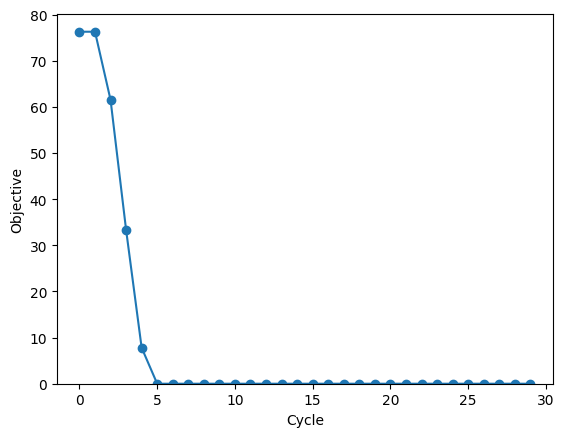

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)